# LeetCode #187: Repeated DNA Sequences

https://leetcode.com/problems/repeated-dna-sequences/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| HashSet of Substrings ★ | O(n) | O(n) |
| Rolling Hash (Rabin-Karp) | O(n) | O(n) |

## Understanding the Methods
### HashSet of Substrings (Optimal)
Slide a window of length 10 across the string. For each 10-letter substring, check if it was seen before using a HashSet. If seen, add it to the result set. The result set ensures no duplicates in the output.

### Rolling Hash (Rabin-Karp)
Encode each nucleotide as 2 bits (A=0, C=1, G=2, T=3) and maintain a 20-bit rolling hash for each window. This avoids string hashing overhead but the asymptotic complexity is the same.

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<string> FindRepeatedDnaSequences(string s) {
        var seen = new HashSet<string>();
        var result = new HashSet<string>();
        for (int i = 0; i <= s.Length - 10; i++) {
            string sub = s.Substring(i, 10);
            if (!seen.Add(sub)) {
                result.Add(sub);
            }
        }
        return result.ToList();
    }
}

### Python

In [ ]:
class Solution:
    def findRepeatedDnaSequences(self, s: str) -> list[str]:
        seen = set()
        result = set()
        for i in range(len(s) - 9):
            sub = s[i:i+10]
            if sub in seen:
                result.add(sub)
            seen.add(sub)
        return list(result)

### Go

In [ ]:
package main

func findRepeatedDnaSequences(s string) []string {
    seen := make(map[string]bool)
    added := make(map[string]bool)
    var result []string
    for i := 0; i <= len(s)-10; i++ {
        sub := s[i : i+10]
        if seen[sub] && !added[sub] {
            result = append(result, sub)
            added[sub] = true
        }
        seen[sub] = true
    }
    return result
}

### Rust

In [ ]:
use std::collections::HashSet;

pub struct Solution;

impl Solution {
    pub fn find_repeated_dna_sequences(s: String) -> Vec<String> {
        let s = s.as_bytes();
        let mut seen = HashSet::new();
        let mut result = HashSet::new();
        if s.len() < 10 {
            return vec![];
        }
        for i in 0..=s.len() - 10 {
            let sub = &s[i..i + 10];
            if !seen.insert(sub) {
                result.insert(sub);
            }
        }
        result.into_iter()
            .map(|b| String::from_utf8(b.to_vec()).unwrap())
            .collect()
    }
}

fn main() {
    let result = Solution::find_repeated_dna_sequences("AAAAACCCCCAAAAACCCCCCAAAAAGGGTTT".to_string());
    println!("{:?}", result);
}

## Example Scenarios

### 1. Common Case — Two Repeated Sequences

**Input:** `s = "AAAAACCCCCAAAAACCCCCCAAAAAGGGTTT"` (length 31)

Slide a window of length 10. At `i=0`: `AAAAACCCCC` — add to seen. At `i=10`: `AAAAACCCCC` again — already seen, add to result. Similarly `CCCCCAAAAA` appears at `i=5` and `i=15`. Two repeated sequences found.

**WHY it's useful:** Sliding window with two HashSets (`seen` and `result`). Each 10-char substring is checked in $O(1)$ amortized. Total: $O(10n)$ for hashing all substrings.

---

### 2. Slightly Complex — All Overlapping Windows Produce Same Substring

**Input:** `s = "AAAAAAAAAAAAA"` (13 A's)

Windows at `i=0,1,2,3` all produce `AAAAAAAAAA`. First window adds to seen. Windows 1-3 find it already seen and add to result. The result set deduplicates — output is `["AAAAAAAAAA"]` (once).

**WHY it's tricky:** Four windows produce the same string. The result set (HashSet) ensures it appears only once in the output. Without deduplication, the answer would incorrectly list it 3 times.

---

### 3. Edge Case: Time Factor — Periodic Pattern at $n = 10^5$

**Input:** `s = "ACGT"` repeated 25,000 times ($n = 100{,}000$). Pattern period = 4, so only 4 distinct 10-char windows exist.

Number of windows: $n - 9 = 99{,}991$. Substring hashing: $O(10)$ per window = $\sim 1M$ character operations. A rolling hash (2-bit encoding, 20-bit integer) reduces each slide to $O(1)$.

**WHY it tests time:** At $n = 100k$, string hashing costs $O(10n) \approx 1M$ operations. Rabin-Karp rolling hash (encode A=0, C=1, G=2, T=3 in 2 bits) achieves true $O(n)$ by updating the hash in constant time per slide.

---

### 4. Edge Case: Space Factor — All Unique Windows

**Input:** $n = 100{,}000$. Maximum entropy DNA — each 10-char window is unique. $99{,}991$ entries stored in the seen HashSet.

Memory for string keys: $99{,}991 \times 10$ chars $\approx 1$ MB. Result set is empty (no repeats). Rolling hash alternative: $99{,}991$ integers (20 bits each) $\approx 400$ KB — 2.5x savings.

**WHY it tests space:** Maximum distinct substrings means the seen set is as large as possible. The rolling hash variant stores 20-bit integers instead of 10-char strings, significantly reducing memory.

---

### 5. Almost-Impossible — Exactly 10 Characters

**Input:** `s = "ACGTACGTAC"` (length = 10)

Only one window exists: `i=0` to `i=0` (since $n - 10 = 0$). A single window can never be a repeat. Loop runs exactly once. For $n < 10$, the loop condition `i <= n - 10` is never satisfied (returns empty immediately).

**WHY it's extreme:** Minimum valid input length. Tests the boundary condition: the loop `for i in range(n - 9)` runs exactly once for $n = 10$, and zero times for $n < 10$. Off-by-one errors in the window bound are the most common bug.

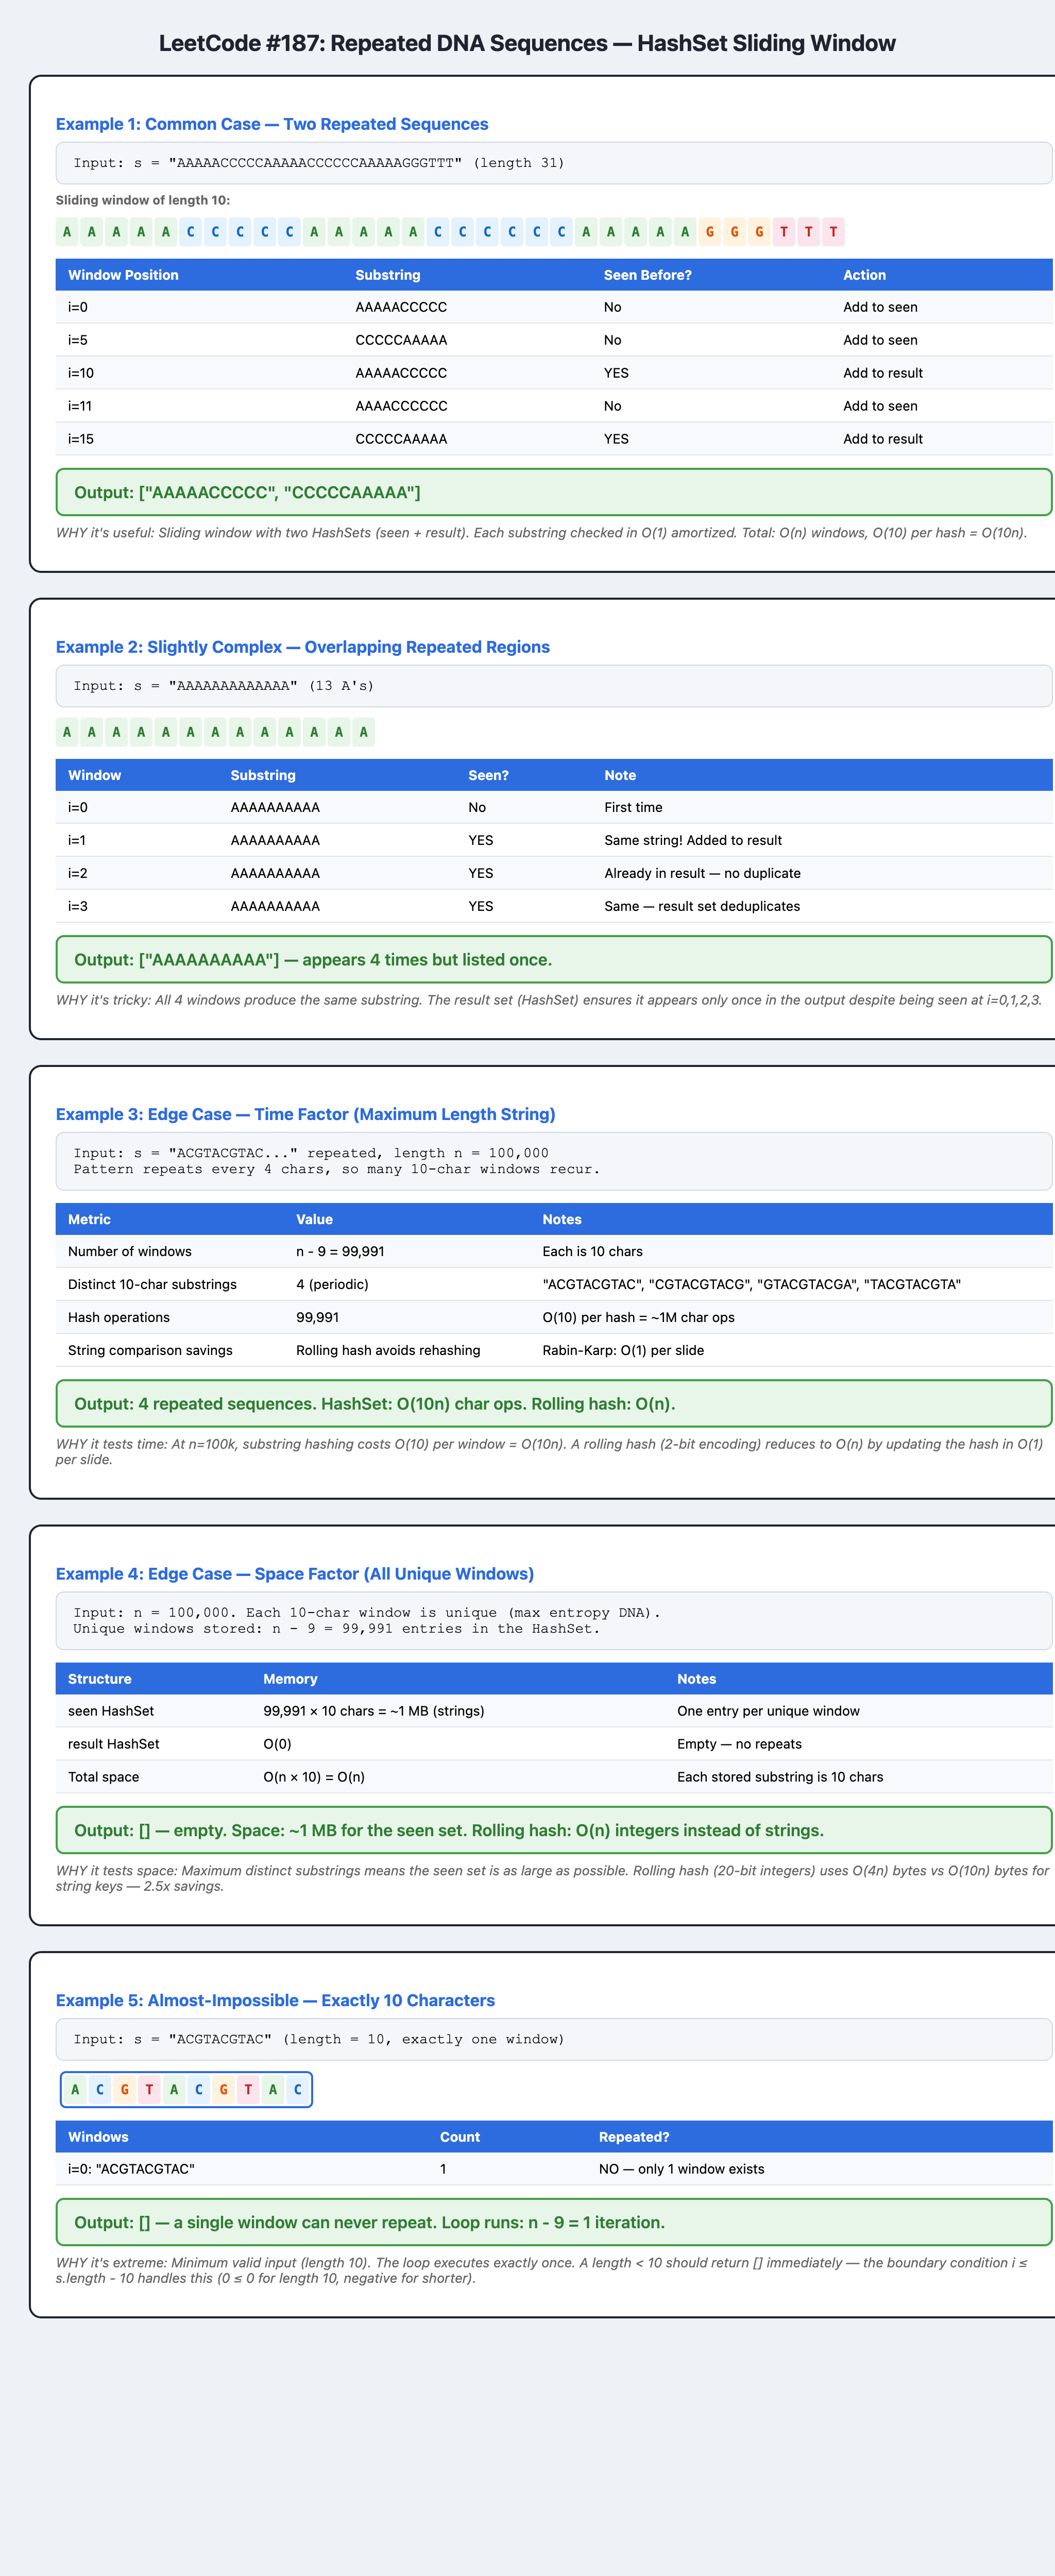